### EDA

In [26]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [27]:
# load the cleaned dataset
df = pd.read_csv("cleaned_adult_dataset.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 48842
Columns: 20


In [28]:
# Measure proportion of records above $50K

income_counts = df["income"].value_counts()

print(income_counts)

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [29]:
# calculate percentage
income_percentage = (
    df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(income_percentage)

income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_15480\2466791787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="income", palette="Blues")


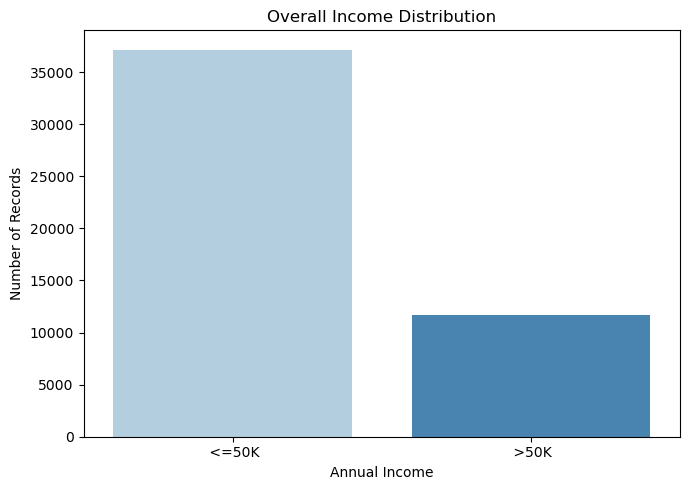

In [30]:
# Create the overall income distribution chart

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="income", palette="Blues")

plt.title("Overall Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Records")
plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "overall_income_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [31]:
#set path for charts
import os

charts_path = r"E:\adult_income_eda_project\report\charts"

os.makedirs(charts_path, exist_ok=True)

In [45]:
df = pd.read_csv(
    r"E:\adult_income_eda_project\data\cleaned_adult_dataset.csv"
)

print(df["high_income"].value_counts())

high_income
0    37155
1    11687
Name: count, dtype: int64


In [46]:
df.to_csv(
    r"E:\adult_income_eda_project\data\cleaned_adult_dataset.csv",
    index=False
)

print("SAVED:", r"E:\adult_income_eda_project\data\cleaned_adult_dataset.csv")

SAVED: E:\adult_income_eda_project\data\cleaned_adult_dataset.csv


In [47]:
test_df = pd.read_csv(
    r"E:\adult_income_eda_project\data\cleaned_adult_dataset.csv"
)

print(test_df["high_income"].value_counts())

print("\nCross-check:")
print(pd.crosstab(test_df["income"], test_df["high_income"]))

high_income
0    37155
1    11687
Name: count, dtype: int64

Cross-check:
high_income      0      1
income                   
<=50K        37155      0
>50K             0  11687


In [48]:
# overall income proportion
income_proportion = (
    df["high_income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(income_proportion)

high_income
0    76.07
1    23.93
Name: proportion, dtype: float64


In [49]:
income_summary = pd.DataFrame({
    "Income Group": ["<=50K", ">50K"],
    "Count": [
        (df["high_income"] == 0).sum(),
        (df["high_income"] == 1).sum()
    ],
    "Percentage": [
        round((df["high_income"] == 0).mean() * 100, 2),
        round((df["high_income"] == 1).mean() * 100, 2)
    ]
})

print(income_summary)

  Income Group  Count  Percentage
0        <=50K  37155       76.07
1         >50K  11687       23.93


In [50]:
import os

charts_path = r"E:\adult_income_eda_project\report\charts"

os.makedirs(charts_path, exist_ok=True)

print("Chart folder:", charts_path)

Chart folder: E:\adult_income_eda_project\report\charts


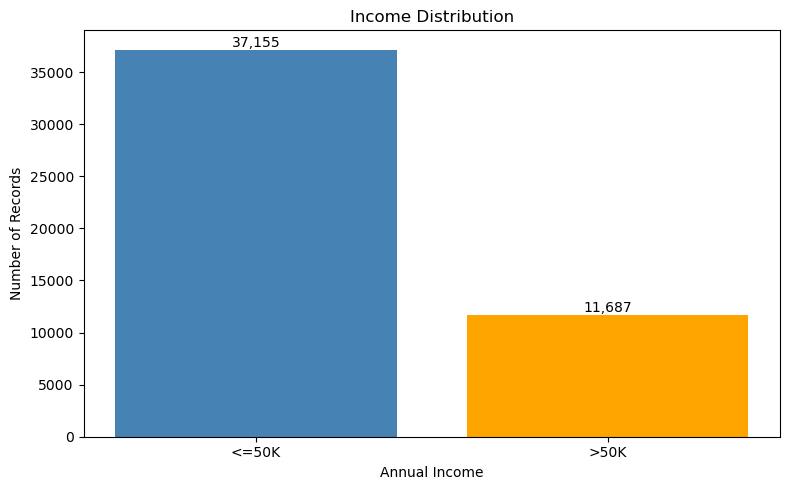

In [51]:
# Income distribution using the corrected high_income column

income_counts = df["high_income"].value_counts().sort_index()

labels = ["<=50K", ">50K"]
counts = [
    income_counts.get(0, 0),
    income_counts.get(1, 0)
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    counts,
    color=["steelblue", "orange"]
)

plt.title("Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Records")

# Add values on top of bars
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "income_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [52]:
# Education vs above-$50K Rate

education_income_rate = (
    df.groupby("education", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print(education_income_rate.sort_values(ascending=False))

education
Prof-school     73.98
Doctorate       72.56
Masters         54.91
Bachelors       41.28
Assoc-acdm      25.80
Assoc-voc       25.33
Some-college    18.96
HS-grad         15.86
12th             7.31
7th-8th          6.49
10th             6.26
9th              5.42
5th-6th          5.30
11th             5.08
1st-4th          3.24
Preschool        1.20
Name: high_income, dtype: float64


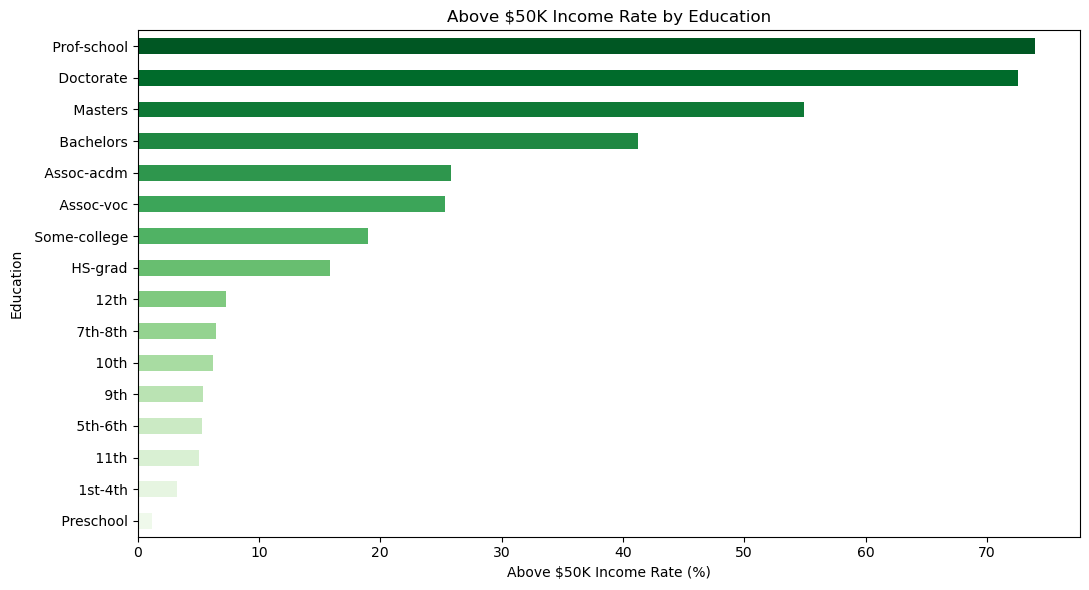

In [53]:
plt.figure(figsize=(11, 6))

education_income_rate.sort_values().plot(
    kind="barh",
    color=sns.color_palette("Greens", n_colors=len(education_income_rate))
)

plt.title("Above $50K Income Rate by Education")
plt.xlabel("Above $50K Income Rate (%)")
plt.ylabel("Education")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "education_income_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Insight:

#The proportion of records above $50K varies across education categories. The chart describes an association between education level and income classification in this dataset.

In [54]:
# Occupation vs Above-$50K Rate
occupation_income_rate = (
    df.groupby("occupation", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print(occupation_income_rate.sort_values(ascending=False))


occupation
Exec-managerial      47.78
Prof-specialty       45.11
Armed-Forces         33.33
Protective-serv      31.33
Tech-support         29.05
Sales                26.80
Craft-repair         22.63
Transport-moving     20.42
Adm-clerical         13.69
Machine-op-inspct    12.31
Farming-fishing      11.61
?                     9.43
Handlers-cleaners     6.66
Other-service         4.14
Priv-house-serv       1.24
Name: high_income, dtype: float64


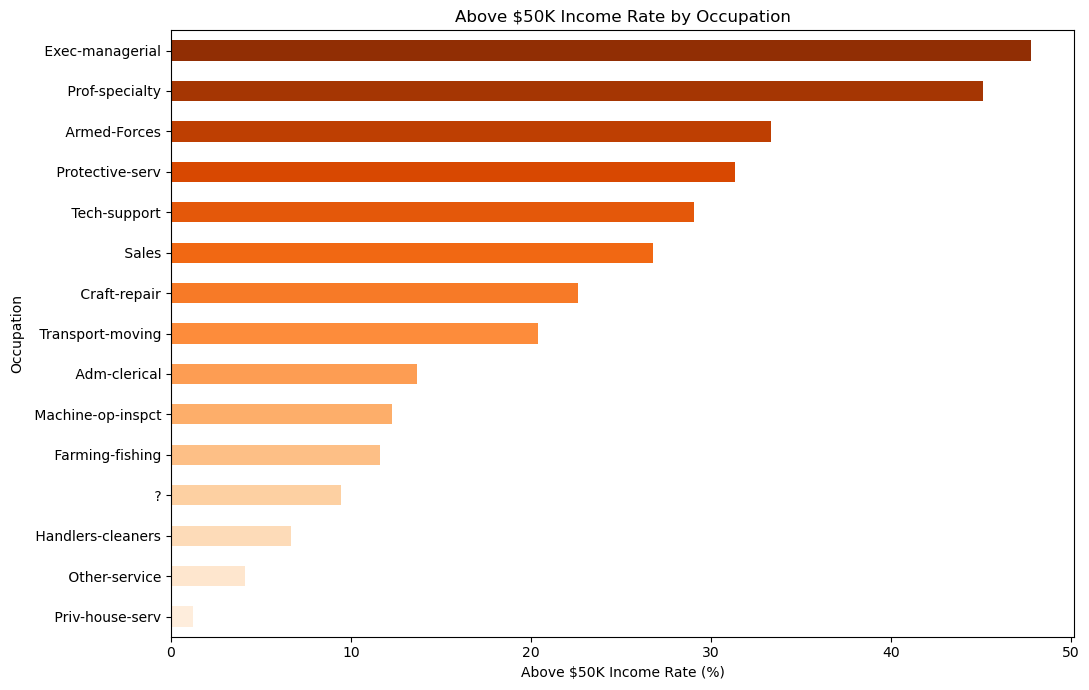

In [55]:
plt.figure(figsize=(11, 7))

occupation_income_rate.sort_values().plot(
    kind="barh",
    color=sns.color_palette("Oranges", n_colors=len(occupation_income_rate))
)

plt.title("Above $50K Income Rate by Occupation")
plt.xlabel("Above $50K Income Rate (%)")
plt.ylabel("Occupation")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "occupation_income_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Age Group vs Above-$50K Rate

age_income_rate = (
    df.groupby("age_group", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print(age_income_rate)

age_group
25-34       16.82
35-44       33.29
45-54       39.39
55-64       32.16
65+         20.46
Under 25     1.10
Name: high_income, dtype: float64


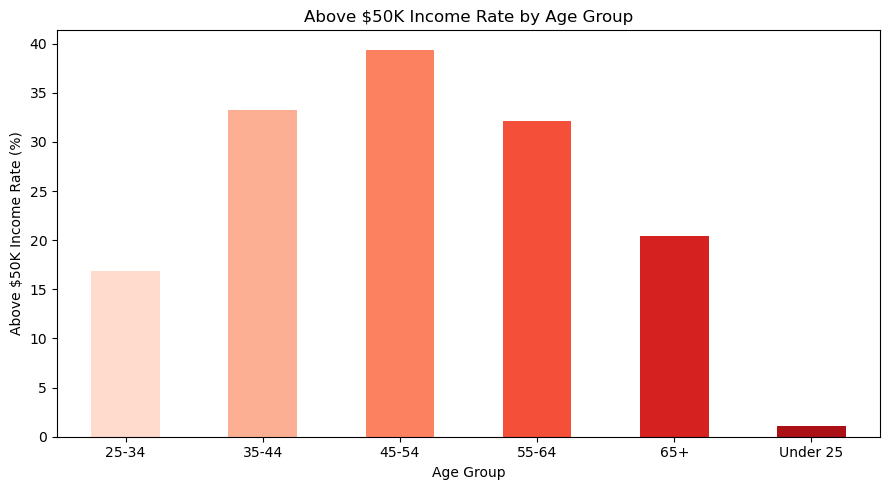

In [57]:
plt.figure(figsize=(9, 5))

age_income_rate.plot(
    kind="bar",
    color=sns.color_palette("Reds", n_colors=len(age_income_rate))
)

plt.title("Above $50K Income Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Above $50K Income Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "age_group_income_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Work Class vs Above-$50K Rate

workclass_income_rate = (
    df.groupby("workclass", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print(workclass_income_rate.sort_values(ascending=False))

workclass
Self-emp-inc        55.34
Federal-gov         39.18
Local-gov           29.56
Self-emp-not-inc    27.89
State-gov           26.75
Private             21.79
Without-pay          9.52
?                    9.47
Never-worked         0.00
Name: high_income, dtype: float64


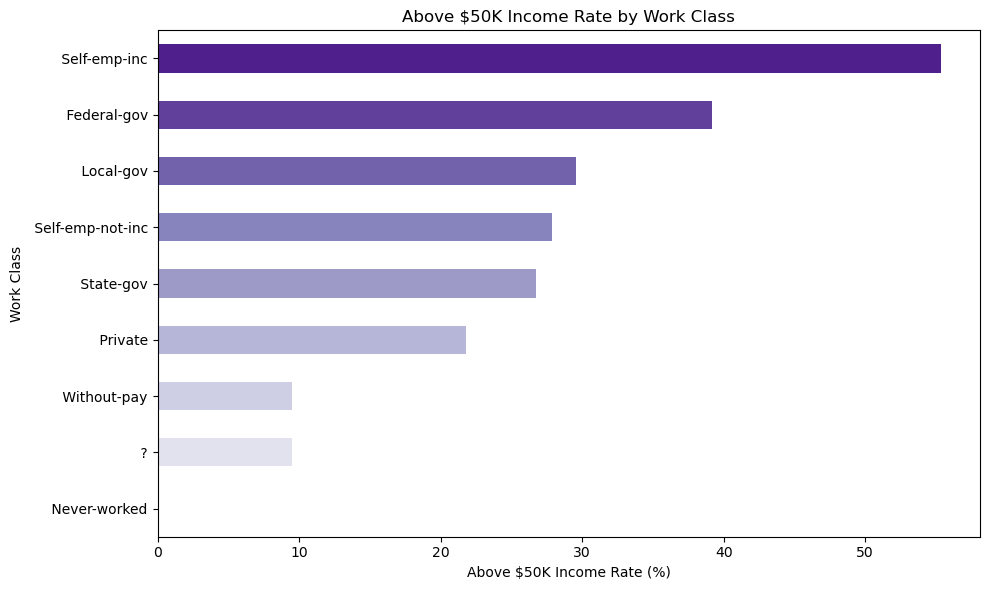

In [59]:
plt.figure(figsize=(10, 6))

workclass_income_rate.sort_values().plot(
    kind="barh",
    color=sns.color_palette("Purples", n_colors=len(workclass_income_rate))
)

plt.title("Above $50K Income Rate by Work Class")
plt.xlabel("Above $50K Income Rate (%)")
plt.ylabel("Work Class")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "workclass_income_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [60]:
# Sex vs Above-$50K Rate

sex_income_rate = (
    df.groupby("sex", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print(sex_income_rate)

sex
Female    10.93
Male      30.38
Name: high_income, dtype: float64


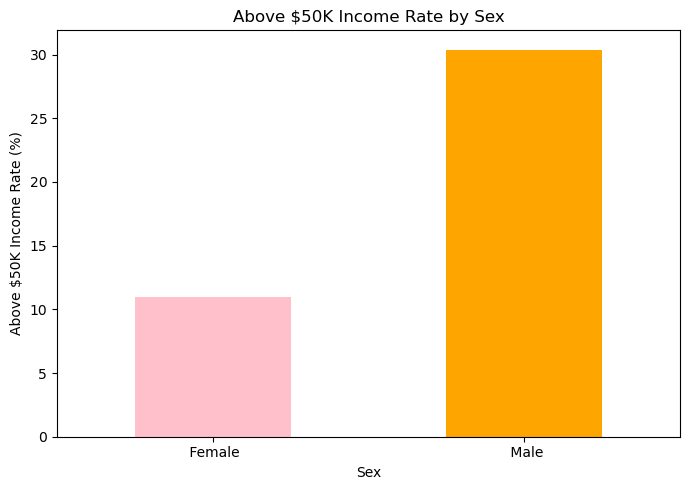

In [61]:
plt.figure(figsize=(7, 5))

sex_income_rate.plot(
    kind="bar",
    color=["pink", "orange"]
)

plt.title("Above $50K Income Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Above $50K Income Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "sex_income_rate.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight:

#The above-$50K rate differs between the sex categories represented in the dataset. This is a descriptive association and should not be interpreted as a causal effect.

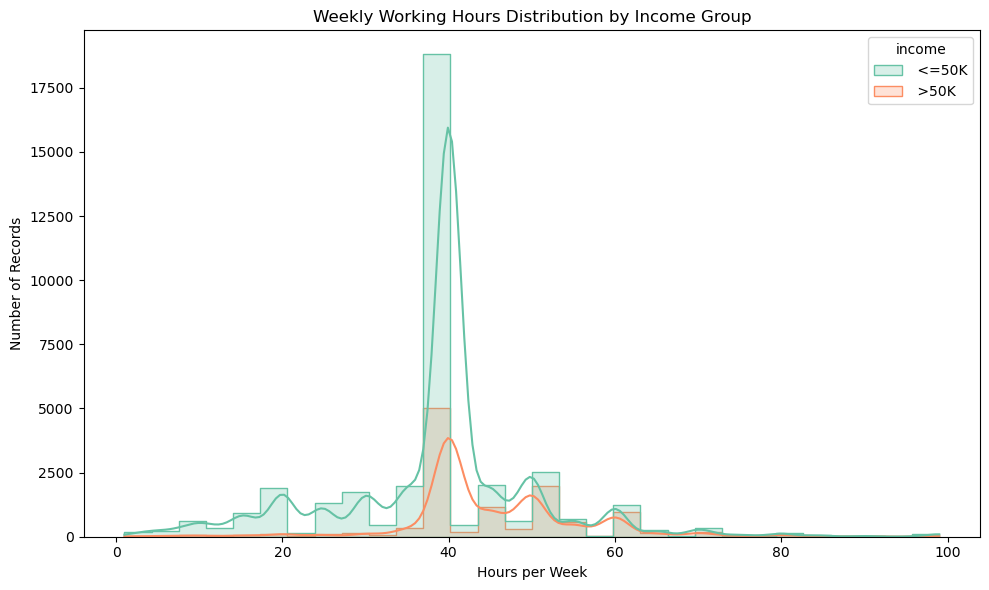

In [62]:
# Weekly Working Hours by Income Group
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hours_per_week",
    hue="income",
    bins=30,
    kde=True,
    palette="Set2",
    element="step",
    stat="count"
)

plt.title("Weekly Working Hours Distribution by Income Group")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "weekly_hours_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight:

#The distributions and summary statistics allow comparison of weekly working hours between the two income groups.


In [63]:
hours_summary = (
    df.groupby("income", observed=True)["hours_per_week"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print(hours_summary)

        count   mean  median  min  max
income                                
<=50K   37155  38.84    40.0    1   99
>50K    11687  45.45    40.0    1   99


In [64]:
# Numeric Relationships — Correlation Heatmap

numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "net_capital",
    "high_income"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix.round(2))

                 age  fnlwgt  education_num  capital_gain  capital_loss  \
age             1.00   -0.08           0.03          0.08          0.06   
fnlwgt         -0.08    1.00          -0.04         -0.00         -0.00   
education_num   0.03   -0.04           1.00          0.13          0.08   
capital_gain    0.08   -0.00           0.13          1.00         -0.03   
capital_loss    0.06   -0.00           0.08         -0.03          1.00   
hours_per_week  0.07   -0.01           0.14          0.08          0.05   
net_capital     0.07   -0.00           0.12          1.00         -0.09   
high_income     0.23   -0.01           0.33          0.22          0.15   

                hours_per_week  net_capital  high_income  
age                       0.07         0.07         0.23  
fnlwgt                   -0.01        -0.00        -0.01  
education_num             0.14         0.12         0.33  
capital_gain              0.08         1.00         0.22  
capital_loss              0.0

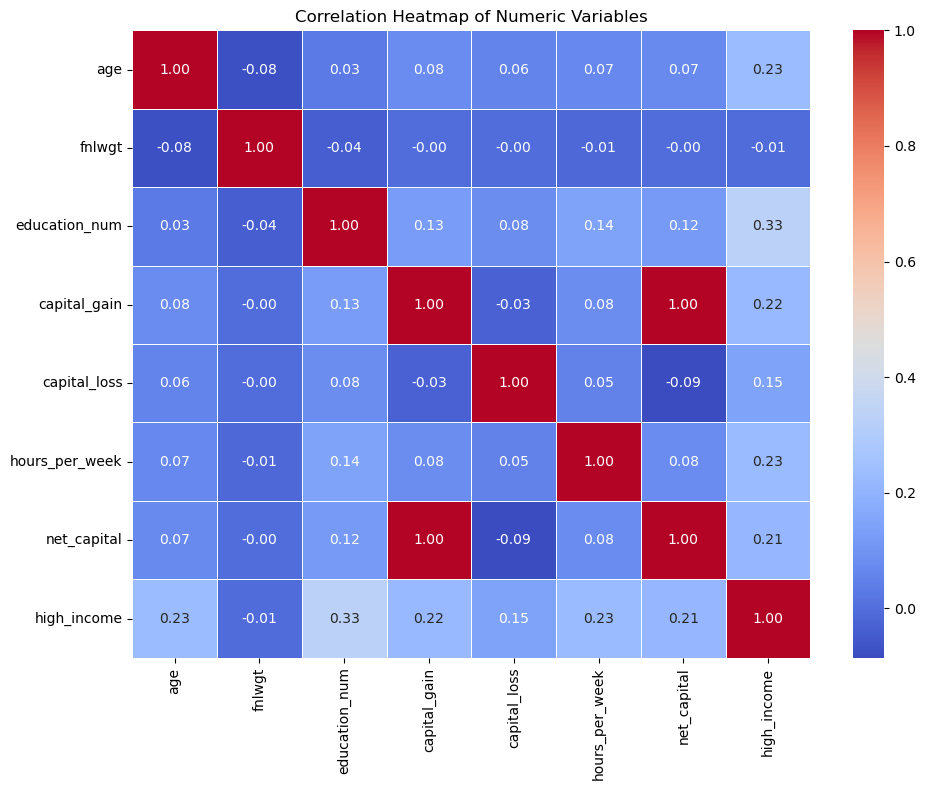

In [65]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "numeric_correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Insight:

#The heatmap summarizes linear relationships among the numeric variables. Correlation indicates association, not causation.

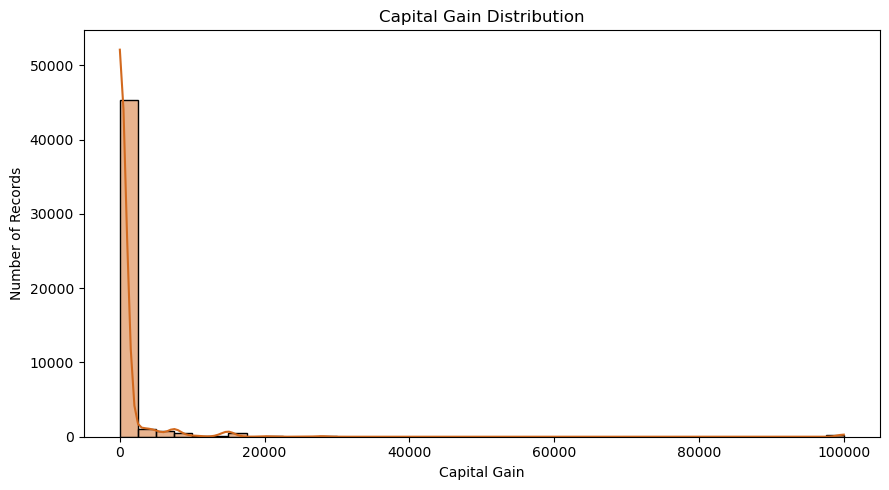

In [66]:
# Capital Gain Distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="capital_gain",
    bins=40,
    kde=True,
    color="chocolate"
)

plt.title("Capital Gain Distribution")
plt.xlabel("Capital Gain")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    os.path.join(charts_path, "capital_gain_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
print("Saved charts:\n")

for file in sorted(os.listdir(charts_path)):
    print(file)

Saved charts:

age_group_income_rate.png
capital_gain_distribution.png
education_income_rate.png
income_distribution.png
numeric_correlation_heatmap.png
occupation_income_rate.png
overall_income_distribution.png
sex_income_rate.png
weekly_hours_distribution.png
workclass_income_rate.png


In [68]:
# Save EDA results / tables
import os
import pandas as pd

# Create report/tables folder
tables_path = r"E:\adult_income_eda_project\report\tables"
os.makedirs(tables_path, exist_ok=True)


# 1. Overall income distribution
income_counts = (
    df["high_income"]
    .value_counts()
    .sort_index()
)

income_summary = pd.DataFrame({
    "Income Group": ["<=50K", ">50K"],
    "Count": [
        income_counts.get(0, 0),
        income_counts.get(1, 0)
    ],
    "Percentage": [
        round((income_counts.get(0, 0) / len(df)) * 100, 2),
        round((income_counts.get(1, 0) / len(df)) * 100, 2)
    ]
})

income_summary.to_csv(
    os.path.join(tables_path, "overall_income_summary.csv"),
    index=False
)


# 2. Education income rate
education_summary = (
    df.groupby("education", observed=True)["high_income"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Records",
        "sum": "Above 50K Count",
        "mean": "Above 50K Rate"
    })
)

education_summary["Above 50K Rate"] = (
    education_summary["Above 50K Rate"] * 100
).round(2)

education_summary = education_summary.sort_values(
    "Above 50K Rate",
    ascending=False
)

education_summary.to_csv(
    os.path.join(tables_path, "education_income_rate.csv")
)


# 3. Occupation income rate
occupation_summary = (
    df.groupby("occupation", observed=True)["high_income"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Records",
        "sum": "Above 50K Count",
        "mean": "Above 50K Rate"
    })
)

occupation_summary["Above 50K Rate"] = (
    occupation_summary["Above 50K Rate"] * 100
).round(2)

occupation_summary = occupation_summary.sort_values(
    "Above 50K Rate",
    ascending=False
)

occupation_summary.to_csv(
    os.path.join(tables_path, "occupation_income_rate.csv")
)


# 4. Age group income rate
age_summary = (
    df.groupby("age_group", observed=True)["high_income"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Records",
        "sum": "Above 50K Count",
        "mean": "Above 50K Rate"
    })
)

age_summary["Above 50K Rate"] = (
    age_summary["Above 50K Rate"] * 100
).round(2)

age_summary.to_csv(
    os.path.join(tables_path, "age_group_income_rate.csv")
)


# 5. Work class income rate
workclass_summary = (
    df.groupby("workclass", observed=True)["high_income"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Records",
        "sum": "Above 50K Count",
        "mean": "Above 50K Rate"
    })
)

workclass_summary["Above 50K Rate"] = (
    workclass_summary["Above 50K Rate"] * 100
).round(2)

workclass_summary = workclass_summary.sort_values(
    "Above 50K Rate",
    ascending=False
)

workclass_summary.to_csv(
    os.path.join(tables_path, "workclass_income_rate.csv")
)


# 6. Sex income rate
sex_summary = (
    df.groupby("sex", observed=True)["high_income"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "Total Records",
        "sum": "Above 50K Count",
        "mean": "Above 50K Rate"
    })
)

sex_summary["Above 50K Rate"] = (
    sex_summary["Above 50K Rate"] * 100
).round(2)

sex_summary.to_csv(
    os.path.join(tables_path, "sex_income_rate.csv")
)


# 7. Weekly working hours summary
hours_summary = (
    df.groupby("income", observed=True)["hours_per_week"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

hours_summary.to_csv(
    os.path.join(tables_path, "weekly_hours_summary.csv")
)


# 8. Numeric relationships / correlation matrix
numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "net_capital",
    "high_income"
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
    .round(3)
)

correlation_matrix.to_csv(
    os.path.join(tables_path, "numeric_correlation_matrix.csv")
)


print("All EDA summary tables saved successfully.")

print("\nSaved files:")
for file in sorted(os.listdir(tables_path)):
    print(file)

All EDA summary tables saved successfully.

Saved files:
age_group_income_rate.csv
education_income_rate.csv
numeric_correlation_matrix.csv
occupation_income_rate.csv
overall_income_summary.csv
sex_income_rate.csv
weekly_hours_summary.csv
workclass_income_rate.csv


In [69]:
# Generate EDA insights
print("=" * 70)
print("ADULT INCOME DATASET - EDA INSIGHTS")
print("=" * 70)


# 1. Overall income distribution
income_counts = df["high_income"].value_counts()

low_income_count = income_counts.get(0, 0)
high_income_count = income_counts.get(1, 0)

low_income_pct = round((low_income_count / len(df)) * 100, 2)
high_income_pct = round((high_income_count / len(df)) * 100, 2)

print("\n1. OVERALL INCOME DISTRIBUTION")
print(f"<=50K: {low_income_count:,} records ({low_income_pct}%)")
print(f">50K : {high_income_count:,} records ({high_income_pct}%)")


# 2. Education
education_rate = (
    df.groupby("education", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("\n2. EDUCATION")
print(education_rate)

print(
    "\nFinding:",
    "Above-50K income rates vary across education levels."
)


# 3. Occupation
occupation_rate = (
    df.groupby("occupation", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("\n3. OCCUPATION")
print(occupation_rate)

print(
    "\nFinding:",
    "Above-50K income rates vary across occupation categories."
)


# 4. Age group
age_rate = (
    df.groupby("age_group", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print("\n4. AGE GROUP")
print(age_rate)

print(
    "\nFinding:",
    "Above-50K income rates differ across age groups."
)


# 5. Work class
workclass_rate = (
    df.groupby("workclass", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print("\n5. WORK CLASS")
print(workclass_rate)

print(
    "\nFinding:",
    "Above-50K income rates vary across work-class categories."
)


# 6. Sex
sex_rate = (
    df.groupby("sex", observed=True)["high_income"]
    .mean()
    .mul(100)
    .round(2)
)

print("\n6. SEX")
print(sex_rate)

print(
    "\nFinding:",
    "The observed above-50K income rates differ between sex groups."
)


# 7. Weekly working hours
hours_summary = (
    df.groupby("income", observed=True)["hours_per_week"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\n7. WEEKLY WORKING HOURS")
print(hours_summary)

print(
    "\nFinding:",
    "Weekly working-hour distributions differ between the two income groups."
)


# 8. Numeric relationships
numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "net_capital",
    "high_income"
]

correlation_matrix = df[numeric_columns].corr()

print("\n8. NUMERIC RELATIONSHIPS")
print(correlation_matrix["high_income"].sort_values(ascending=False).round(3))

print(
    "\nFinding:",
    "Numeric variables show different levels of association with the income indicator."
)


# 9. Capital gain observation
print("\n9. CAPITAL GAIN")
print(
    df["capital_gain"]
    .describe()
    .round(2)
)

print(
    "\nFinding:",
    "Capital gain is highly concentrated at low or zero values, "
    "with a smaller number of substantially larger observations."
)


# 10. Overall conclusion
print("\n" + "=" * 70)
print("OVERALL EDA CONCLUSION")
print("=" * 70)

print(
    "The analysis shows that above-50K income rates vary across "
    "education, occupation, age group, work class, and sex. "
    "Weekly working hours and several numeric variables also show "
    "different patterns between income groups."
)

print(
    "\nImportant limitation:",
    "These are descriptive associations from an observational dataset. "
    "They do not establish that any demographic, education, or work "
    "characteristic causes higher income."
)

ADULT INCOME DATASET - EDA INSIGHTS

1. OVERALL INCOME DISTRIBUTION
<=50K: 37,155 records (76.07%)
>50K : 11,687 records (23.93%)

2. EDUCATION
education
Prof-school     73.98
Doctorate       72.56
Masters         54.91
Bachelors       41.28
Assoc-acdm      25.80
Assoc-voc       25.33
Some-college    18.96
HS-grad         15.86
12th             7.31
7th-8th          6.49
10th             6.26
9th              5.42
5th-6th          5.30
11th             5.08
1st-4th          3.24
Preschool        1.20
Name: high_income, dtype: float64

Finding: Above-50K income rates vary across education levels.

3. OCCUPATION
occupation
Exec-managerial      47.78
Prof-specialty       45.11
Armed-Forces         33.33
Protective-serv      31.33
Tech-support         29.05
Sales                26.80
Craft-repair         22.63
Transport-moving     20.42
Adm-clerical         13.69
Machine-op-inspct    12.31
Farming-fishing      11.61
?                     9.43
Handlers-cleaners     6.66
Other-service       